<a href="https://colab.research.google.com/github/Fernanfds/Fernanfds/blob/main/Tratamento_de_dados_com_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [6]:
URL = "https://www.ipeadata.gov.br/ExibeSerie.aspx?stub=1&serid=36482&module=M"

In [7]:
tabelas = pd.read_html(URL)
tabelas

[    0                                                  1
 0 NaN  Ãndice nacional de preÃ§os ao consumidor ampl...,
                                                    0
 0  Data IPCA - geral - Ã­ndice (dez. 1993 = 100) ...,
            0                                         1
 0       Data  IPCA - geral - Ã­ndice (dez. 1993 = 100)
 1    1979.12                                 76183E-09
 2    1980.01                                 81223E-09
 3    1980.02                                 84973E-09
 4    1980.03                                 90104E-09
 ..       ...                                       ...
 544  2025.03                                7.245,3800
 545  2025.04                                7.276,5400
 546  2025.05                                7.295,4600
 547  2025.06                                7.312,9700
 548  2025.07                                7.331,9800
 
 [549 rows x 2 columns],
       0   1
 0  Data NaN,
                                           0   1

In [8]:
len(tabelas)

5

In [9]:
tabela = tabelas[2]
tabela

,0,1
0,Data,IPCA - geral - Ã­ndice (dez. 1993 = 100)
1,1979.12,76183E-09
2,1980.01,81223E-09
3,1980.02,84973E-09
4,1980.03,90104E-09
...,...,...
544,2025.03,"7.245,3800"
545,2025.04,"7.276,5400"
546,2025.05,"7.295,4600"
547,2025.06,"7.312,9700"


In [10]:
df_ipca = tabela.copy()
df_ipca.columns = df_ipca.iloc[0]

df_ipca

,Data,IPCA - geral - Ã­ndice (dez. 1993 = 100)
0,Data,IPCA - geral - Ã­ndice (dez. 1993 = 100)
1,1979.12,76183E-09
2,1980.01,81223E-09
3,1980.02,84973E-09
4,1980.03,90104E-09
...,...,...
544,2025.03,"7.245,3800"
545,2025.04,"7.276,5400"
546,2025.05,"7.295,4600"
547,2025.06,"7.312,9700"


In [11]:
df_ipca = df_ipca.drop(0)
df_ipca

,Data,IPCA - geral - Ã­ndice (dez. 1993 = 100)
1,1979.12,76183E-09
2,1980.01,81223E-09
3,1980.02,84973E-09
4,1980.03,90104E-09
5,1980.04,94867E-09
...,...,...
544,2025.03,"7.245,3800"
545,2025.04,"7.276,5400"
546,2025.05,"7.295,4600"
547,2025.06,"7.312,9700"


In [12]:
df_ipca = df_ipca.set_index("Data")
df_ipca

,IPCA - geral - Ã­ndice (dez. 1993 = 100)
Data,
1979.12,76183E-09
1980.01,81223E-09
1980.02,84973E-09
1980.03,90104E-09
1980.04,94867E-09
...,...
2025.03,"7.245,3800"
2025.04,"7.276,5400"
2025.05,"7.295,4600"


In [13]:
df_ipca.index = pd.to_datetime(df_ipca.index, format= "%Y.%m")
df_ipca

DatetimeIndex(['1979-12-01', '1980-01-01', '1980-02-01', '1980-03-01',
               '1980-04-01', '1980-05-01', '1980-06-01', '1980-07-01',
               '1980-08-01', '1980-09-01',
               ...
               '2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01',
               '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01',
               '2025-06-01', '2025-07-01'],
              dtype='datetime64[ns]', name='Data', length=548, freq=None)

In [ ]:
df_ipca.columns = ["IPCA"]
df_ipca.info()

In [18]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
df_ipca_recorte = df_ipca.loc["1993-12-01":]
df_ipca_recorte

,IPCA
Data,
1993-12-01,1000000
1994-01-01,1413100
1994-02-01,1982200
1994-03-01,2829600
1994-04-01,4037300
...,...
2025-03-01,"7.245,3800"
2025-04-01,"7.276,5400"
2025-05-01,"7.295,4600"


In [25]:
# df_ipca_recorte["IPCA"] = df_ipca_recorte["IPCA"].str.replace(".", "")
# df_ipca_recorte["IPCA"] = df_ipca_recorte["IPCA"].str.replace(",", ".")

df_ipca_recorte["IPCA"] = df_ipca_recorte["IPCA"].astype(float)

df_ipca_recorte

,IPCA
Data,
1993-12-01,1000000.0
1994-01-01,1413100.0
1994-02-01,1982200.0
1994-03-01,2829600.0
1994-04-01,4037300.0
...,...
2025-03-01,72453800.0
2025-04-01,72765400.0
2025-05-01,72954600.0


In [ ]:
df_ipca_recorte.head(24)

<Axes: title={'center': 'IPCA'}, xlabel='Data'>

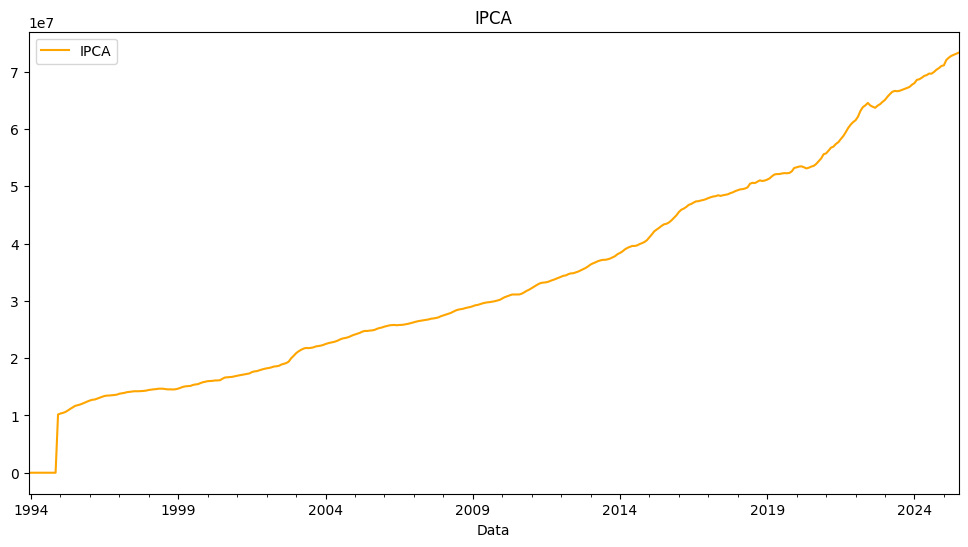

In [31]:
df_ipca_recorte.loc["1993-12-01":"1994-11-01"] /= 10e3
df_ipca_recorte.plot(figsize=(12, 6),color="orange", title="IPCA")